In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
)

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("Telco_customer_churn copy.csv")

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df.loc[
    (df["Total Charges"].isna()) &
    (df["Tenure Months"] == 0),
    "Total Charges"
] = 0

In [6]:
df["Churn"] = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})


In [7]:
df["tenure_bucket"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

df["charge_per_tenure"] = (
    df["Total Charges"] /
    (df["Tenure Months"] + 1)
)

service_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df["num_additional_services"] = (
    df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)


In [8]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "charge_per_tenure",
    "num_additional_services"
]

categorical_features = [
    "Contract",
    "tenure_bucket"
]

features = numeric_features + categorical_features

X = df[features].copy()
y = df["Churn"].copy()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [10]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


## PART B1

In [11]:
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)


In [12]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])



In [13]:
param_dist = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 4, 6, 8]
}



In [14]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#randomsearch

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)


In [15]:
search.fit(X_train, y_train)



print("Best parameters:")
print(search.best_params_)



print("\nBest CV F1:")
print(search.best_score_)



best_xgb = search.best_estimator_



Best parameters:
{'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1}

Best CV F1:
0.563765951030151


## PART B3:

In [16]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# --------------------------------------------------
# 1. Split the B1 training data into:
#    training data + validation data
# --------------------------------------------------

X_train_es, X_val_es, y_train_es, y_val_es = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)


# --------------------------------------------------
# 2. Fit preprocessing ONLY on the training portion
# --------------------------------------------------

X_train_es_transformed = preprocessor.fit_transform(X_train_es)
X_val_es_transformed = preprocessor.transform(X_val_es)


# --------------------------------------------------
# 3. Create XGBoost with early stopping
# --------------------------------------------------

xgb_es = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=42
)


# --------------------------------------------------
# 4. Train with validation set
# --------------------------------------------------

xgb_es.fit(
    X_train_es_transformed,
    y_train_es,
    eval_set=[
        (X_val_es_transformed, y_val_es)
    ],
    verbose=False
)


# --------------------------------------------------
# 5. Print best iteration
# --------------------------------------------------

print("Best iteration:", xgb_es.best_iteration)

Best iteration: 120


## PART B2

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# --------------------------------------------------
# 1. Preprocessing for SVM
# --------------------------------------------------

svm_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


# --------------------------------------------------
# 2. Fit preprocessing ONLY on training data
# --------------------------------------------------

X_train_s = svm_preprocessor.fit_transform(X_train)

X_test_s = svm_preprocessor.transform(X_test)


# --------------------------------------------------
# 3. Compare Linear and RBF SVM
# --------------------------------------------------

for kernel in ["linear", "rbf"]:

    model = SVC(
        kernel=kernel,
        C=1.0
    )

    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print(f"{kernel} SVM F1: {f1:.4f}")

linear SVM F1: 0.4902
rbf SVM F1: 0.4875


here linear F1 score is higher and it performed  better


## PART B4

In [24]:
# ============================================================
# B4 — RBF SVM vs Tuned XGBoost
# ============================================================
import time


# ------------------------------------------------------------
# 1. Train RBF SVM
# ------------------------------------------------------------

t0 = time.time()

svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_rbf.fit(
    X_train_s,
    y_train
)

svm_fit_time = time.time() - t0


# ------------------------------------------------------------
# 2. SVM prediction + inference time
# ------------------------------------------------------------

t0 = time.time()

y_svm_pred = svm_rbf.predict(X_test_s)

svm_inference_time = time.time() - t0


# ------------------------------------------------------------
# 3. SVM F1
# ------------------------------------------------------------

svm_f1 = f1_score(
    y_test,
    y_svm_pred,
    zero_division=0
)


# ------------------------------------------------------------
# 4. SVM predicted probabilities
# ------------------------------------------------------------

svm_prob = svm_rbf.predict_proba(X_test_s)[:, 1]


# ------------------------------------------------------------
# 5. Tuned XGBoost prediction + inference time
# ------------------------------------------------------------

t0 = time.time()

y_xgb_pred = best_xgb.predict(X_test)

xgb_inference_time = time.time() - t0


# ------------------------------------------------------------
# 6. XGBoost F1
# ------------------------------------------------------------

xgb_f1 = f1_score(
    y_test,
    y_xgb_pred,
    zero_division=0
)


# ------------------------------------------------------------
# 7. XGBoost predicted probabilities
# ------------------------------------------------------------

xgb_prob = best_xgb.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 8. Print comparison
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("B4 — RBF SVM vs Tuned XGBoost")
print("=" * 55)

print("\nRBF SVM")
print("-" * 30)
print(f"F1 Score:          {svm_f1:.4f}")
print(f"Fit Time:          {svm_fit_time:.4f} seconds")
print(f"Inference Time:    {svm_inference_time:.4f} seconds")

print("\nTuned XGBoost")
print("-" * 30)
print(f"F1 Score:          {xgb_f1:.4f}")
print(f"Inference Time:    {xgb_inference_time:.4f} seconds")

print("\nComparison")
print("-" * 30)
print(f"XGBoost F1:        {xgb_f1:.4f}")
print(f"SVM F1:            {svm_f1:.4f}")


B4 — RBF SVM vs Tuned XGBoost

RBF SVM
------------------------------
F1 Score:          0.4875
Fit Time:          5.5818 seconds
Inference Time:    0.2155 seconds

Tuned XGBoost
------------------------------
F1 Score:          0.5590
Inference Time:    0.0094 seconds

Comparison
------------------------------
XGBoost F1:        0.5590
SVM F1:            0.4875


## PART C:

In [25]:
# ============================================================
# PART C — FINAL MODEL COMPARISON & ANALYSIS
# Gradient Boosting vs RBF SVM
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve


# ============================================================
# 1. REPORT XGBOOST CV TUNING
# ============================================================

print("=" * 65)
print("PART C — FINAL MODEL COMPARISON")
print("=" * 65)

print("\n1. XGBoost Cross-Validation Tuning")
print("-" * 45)

print("Number of CV folds: 5")
print("Number of random hyperparameter combinations: 15")
print("Scoring metric: F1")

print("\nBest XGBoost parameters:")

for param, value in search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest CV F1: {search.best_score_:.4f}")


# ============================================================
# 2. XGBOOST FINAL TEST PERFORMANCE
# ============================================================

print("\n2. Tuned XGBoost Test Performance")
print("-" * 45)

t0 = time.time()

xgb_test_pred = best_xgb.predict(X_test)

xgb_inference_time_c = time.time() - t0

xgb_test_prob = best_xgb.predict_proba(X_test)[:, 1]

xgb_f1_c = f1_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

xgb_precision_c = precision_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

xgb_recall_c = recall_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

xgb_pr_auc_c = average_precision_score(
    y_test,
    xgb_test_prob
)

xgb_roc_auc_c = roc_auc_score(
    y_test,
    xgb_test_prob
)



print(f"F1:             {xgb_f1_c:.4f}")
print(f"Precision:      {xgb_precision_c:.4f}")
print(f"Recall:         {xgb_recall_c:.4f}")
print(f"PR-AUC:         {xgb_pr_auc_c:.4f}")
print(f"ROC-AUC:        {xgb_roc_auc_c:.4f}")
print(f"Inference Time: {xgb_inference_time_c:.6f} seconds")


# ============================================================
# 3. SVM TEST PERFORMANCE
# ============================================================

print("\n3. RBF SVM Test Performance")
print("-" * 45)

# Use the SVM probability already created in B4
svm_test_pred = svm_rbf.predict(X_test_s)

svm_test_prob = svm_rbf.predict_proba(X_test_s)[:, 1]

svm_f1_c = f1_score(
    y_test,
    svm_test_pred,
    zero_division=0
)

svm_precision_c = precision_score(
    y_test,
    svm_test_pred,
    zero_division=0
)

svm_recall_c = recall_score(
    y_test,
    svm_test_pred,
    zero_division=0
)

svm_pr_auc_c = average_precision_score(
    y_test,
    svm_test_prob
)

svm_roc_auc_c = roc_auc_score(
    y_test,
    svm_test_prob
)


print(f"F1:             {svm_f1_c:.4f}")
print(f"Precision:      {svm_precision_c:.4f}")
print(f"Recall:         {svm_recall_c:.4f}")
print(f"PR-AUC:         {svm_pr_auc_c:.4f}")
print(f"ROC-AUC:        {svm_roc_auc_c:.4f}")
print(f"Training Time:  {svm_fit_time:.4f} seconds")
print(f"Inference Time: {svm_inference_time:.6f} seconds")


# ============================================================
# 4. CALIBRATION TABLE — XGBOOST
# ============================================================

print("\n4. XGBoost Calibration")
print("-" * 45)

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test,
    xgb_test_prob,
    n_bins=10,
    strategy="uniform"
)

xgb_calibration_table = pd.DataFrame({
    "Mean Predicted Probability": prob_pred_xgb,
    "Actual Positive Rate": prob_true_xgb
})

print(xgb_calibration_table)


# ============================================================
# 5. CALIBRATION TABLE — SVM
# ============================================================

print("\n5. SVM Calibration")
print("-" * 45)

prob_true_svm, prob_pred_svm = calibration_curve(
    y_test,
    svm_test_prob,
    n_bins=10,
    strategy="uniform"
)

svm_calibration_table = pd.DataFrame({
    "Mean Predicted Probability": prob_pred_svm,
    "Actual Positive Rate": prob_true_svm
})

print(svm_calibration_table)


# ============================================================
# 6. FINAL MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Tuned XGBoost",
        "RBF SVM"
    ],
    "F1": [
        xgb_f1_c,
        svm_f1_c
    ],
    "Precision": [
        xgb_precision_c,
        svm_precision_c
    ],
    "Recall": [
        xgb_recall_c,
        svm_recall_c
    ],
    "PR-AUC": [
        xgb_pr_auc_c,
        svm_pr_auc_c
    ],
    "ROC-AUC": [
        xgb_roc_auc_c,
        svm_roc_auc_c
    ],

    "Training Time (s)": [
        np.nan,
        svm_fit_time
    ],
    "Inference Time (s)": [
        xgb_inference_time_c,
        svm_inference_time
    ]
})

print("\n6. FINAL MODEL COMPARISON")
print("-" * 65)

print(comparison.round(4).to_string(index=False))

PART C — FINAL MODEL COMPARISON

1. XGBoost Cross-Validation Tuning
---------------------------------------------
Number of CV folds: 5
Number of random hyperparameter combinations: 15
Scoring metric: F1

Best XGBoost parameters:
model__n_estimators: 100
model__max_depth: 4
model__learning_rate: 0.1

Best CV F1: 0.5638

2. Tuned XGBoost Test Performance
---------------------------------------------
F1:             0.5590
Precision:      0.6339
Recall:         0.5000
PR-AUC:         0.6386
ROC-AUC:        0.8386
Inference Time: 0.063200 seconds

3. RBF SVM Test Performance
---------------------------------------------
F1:             0.4875
Precision:      0.6489
Recall:         0.3904
PR-AUC:         0.5972
ROC-AUC:        0.7757
Training Time:  5.5818 seconds
Inference Time: 0.215460 seconds

4. XGBoost Calibration
---------------------------------------------
   Mean Predicted Probability  Actual Positive Rate
0                    0.035323              0.043478
1                    0

### Caliration plot


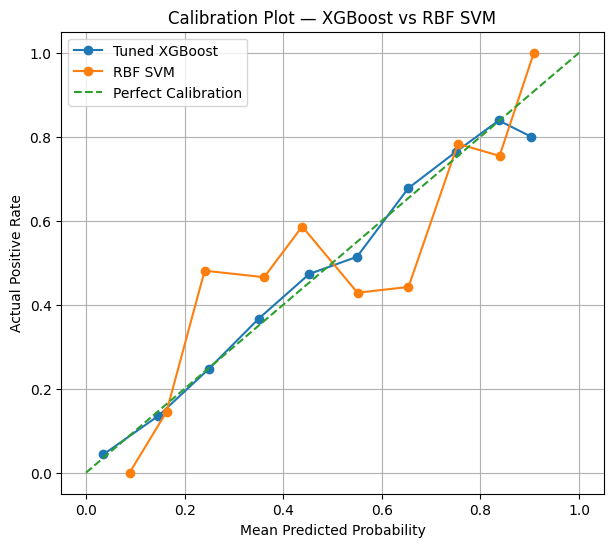

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred_xgb,
    prob_true_xgb,
    marker="o",
    label="Tuned XGBoost"
)

plt.plot(
    prob_pred_svm,
    prob_true_svm,
    marker="o",
    label="RBF SVM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Positive Rate")
plt.title("Calibration Plot — XGBoost vs RBF SVM")
plt.legend()
plt.grid(True)

plt.show()

### saving results

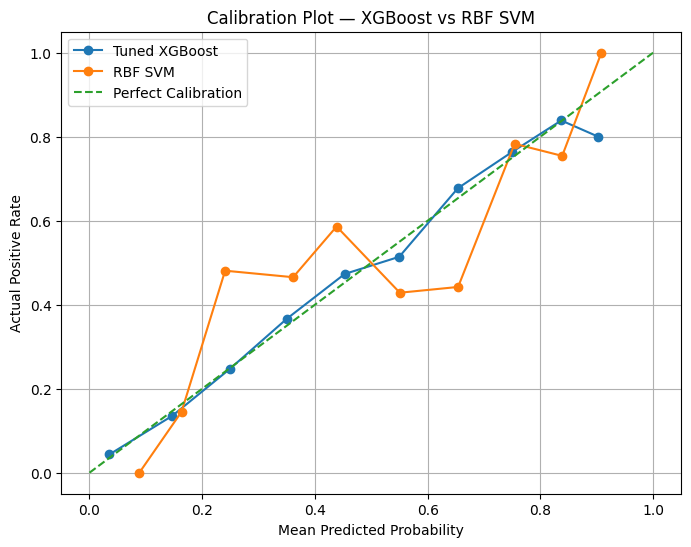


ALL PART C ARTIFACTS SAVED
calibration_plot.png
final_model_comparison.csv
part_c_summary.txt
svm_calibration_table.csv
svm_final_performance.csv
test_probability_predictions.csv
xgboost_best_hyperparameters.json
xgboost_calibration_table.csv
xgboost_cv_results.csv
xgboost_final_performance.csv

Folder:
/content/Part_C_Artifacts


In [29]:
# ============================================================
# SAVE ALL PART C ARTIFACTS
# Run this in YOUR NOTEBOOK after Part C
# ============================================================

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

output_dir = Path("Part_C_Artifacts")
output_dir.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 2. Save XGBoost best hyperparameters
# ------------------------------------------------------------

best_params = {}

for k, v in search.best_params_.items():
    if hasattr(v, "item"):
        v = v.item()
    best_params[k] = v

with open(
    output_dir / "xgboost_best_hyperparameters.json",
    "w"
) as f:
    json.dump(best_params, f, indent=4)


# ------------------------------------------------------------
# 3. Save complete CV results
# ------------------------------------------------------------

cv_results = pd.DataFrame(search.cv_results_)

cv_results.to_csv(
    output_dir / "xgboost_cv_results.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save XGBoost final performance
# ------------------------------------------------------------

xgb_performance = pd.DataFrame([{
    "Model": "Tuned XGBoost",
    "CV_F1": search.best_score_,
    "Test_F1": xgb_f1_c,
    "Precision": xgb_precision_c,
    "Recall": xgb_recall_c,
    "PR_AUC": xgb_pr_auc_c,
    "ROC_AUC": xgb_roc_auc_c,
    "Inference_Time_Seconds": xgb_inference_time_c
}])

xgb_performance.to_csv(
    output_dir / "xgboost_final_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Save SVM final performance
# ------------------------------------------------------------

svm_performance = pd.DataFrame([{
    "Model": "RBF SVM",
    "F1": svm_f1_c,
    "Precision": svm_precision_c,
    "Recall": svm_recall_c,
    "PR_AUC": svm_pr_auc_c,
    "ROC_AUC": svm_roc_auc_c,
    "Training_Time_Seconds": svm_fit_time,
    "Inference_Time_Seconds": svm_inference_time
}])

svm_performance.to_csv(
    output_dir / "svm_final_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 6. Save complete comparison table
# ------------------------------------------------------------

comparison.to_csv(
    output_dir / "final_model_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 7. Save XGBoost calibration table
# ------------------------------------------------------------

xgb_calibration_table.to_csv(
    output_dir / "xgboost_calibration_table.csv",
    index=False
)


# ------------------------------------------------------------
# 8. Save SVM calibration table
# ------------------------------------------------------------

svm_calibration_table.to_csv(
    output_dir / "svm_calibration_table.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Create and save calibration plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_xgb,
    prob_true_xgb,
    marker="o",
    label="Tuned XGBoost"
)

plt.plot(
    prob_pred_svm,
    prob_true_svm,
    marker="o",
    label="RBF SVM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Positive Rate")
plt.title("Calibration Plot — XGBoost vs RBF SVM")

plt.legend()
plt.grid(True)

plt.savefig(
    output_dir / "calibration_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ------------------------------------------------------------
# 10. Save test predictions and probabilities
# ------------------------------------------------------------

probability_predictions = pd.DataFrame({
    "Actual_Churn": y_test.values,

    "XGBoost_Probability": xgb_test_prob,
    "XGBoost_Prediction": xgb_test_pred,

    "SVM_Probability": svm_test_prob,
    "SVM_Prediction": svm_test_pred
})

probability_predictions.to_csv(
    output_dir / "test_probability_predictions.csv",
    index=False
)


# ------------------------------------------------------------
# 11. Save readable Part C summary
# ------------------------------------------------------------

summary = f"""
PART C — FINAL MODEL COMPARISON
================================

XGBOOST CV TUNING
-----------------
CV folds: 5
Randomized combinations: 15
Scoring metric: F1

Best XGBoost parameters:
{json.dumps(best_params, indent=4)}

Best CV F1:
{search.best_score_:.4f}


TUNED XGBOOST TEST PERFORMANCE
------------------------------
F1:          {xgb_f1_c:.4f}
Precision:   {xgb_precision_c:.4f}
Recall:      {xgb_recall_c:.4f}
PR-AUC:      {xgb_pr_auc_c:.4f}
ROC-AUC:     {xgb_roc_auc_c:.4f}

Inference Time:
{xgb_inference_time_c:.6f} seconds


RBF SVM TEST PERFORMANCE
------------------------
F1:          {svm_f1_c:.4f}
Precision:   {svm_precision_c:.4f}
Recall:      {svm_recall_c:.4f}
PR-AUC:      {svm_pr_auc_c:.4f}
ROC-AUC:     {svm_roc_auc_c:.4f}

Training Time:
{svm_fit_time:.4f} seconds

Inference Time:
{svm_inference_time:.6f} seconds


CALIBRATION
-----------
Calibration tables:
- xgboost_calibration_table.csv
- svm_calibration_table.csv

Calibration plot:
- calibration_plot.png

Lower Brier Score indicates better probability accuracy.


MODEL COMPARISON
----------------
{comparison.round(4).to_string(index=False)}
"""

with open(
    output_dir / "part_c_summary.txt",
    "w"
) as f:
    f.write(summary)


# ------------------------------------------------------------
# 12. Show saved files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ALL PART C ARTIFACTS SAVED")
print("=" * 60)

for file in sorted(output_dir.iterdir()):
    print(file.name)

print("\nFolder:")
print(output_dir.resolve())

Recommendation: Tuned XGBoost

For a system that uses the raw predicted churn probability to set a retention-offer budget, I would recommend the tuned XGBoost model based on the results from this experiment.

The key reason is that this system needs reliable probabilities, not just good classification or ranking. XGBoost achieved a higher ROC-AUC (0.8386) and PR-AUC (0.6386) than RBF SVM (0.7757 and 0.5972), indicating stronger discrimination. More importantly, its calibration results are generally closer to the ideal relationship between predicted probability and observed churn rate. For example, XGBoost's predicted probability of approximately 0.75 corresponded to an observed churn rate of 0.764, while its approximately 0.84 prediction corresponded to an observed rate of 0.839.

XGBoost also had better operational performance: its inference time was 0.0632 seconds, compared with 0.2155 seconds for SVM. It also achieved a higher F1 (0.5590 vs 0.4875) and recall (0.5000 vs 0.3904).

Therefore, XGBoost is the better choice for this experiment because its probabilities appear more trustworthy, while it also provides stronger predictive and inference performance.

